# Central Virginia Tree Canopy — Build `smap_df` and `canopy_df`

Assembles the two DataFrames consumed by `1_sagemaker_export.py`:

| DataFrame | Source | Purpose |
|:---|:---|:---|
| `smap_df` | `s3://…/smap-annual-means/*.csv` | SMAP soil moisture time-series chart |
| `canopy_df` | `s3://…/centroids/all_2016_centroids.csv` + `s3://…/chm/all/2016/*_chm.tif` | Tree canopy cover bar chart |

**Kernel:** `conda_python3`  
**Run order:** Run all cells top-to-bottom, then execute `1_sagemaker_export.py` (or paste Cell 11 below).

---
## Cell 1 — Install Extra Dependencies
All packages below are available in `conda_python3`; this cell ensures the correct versions are present.

In [1]:
import subprocess, sys

pkgs = ["rasterio", "pyproj>=3.4", "kaleido", "plotly[kaleido]", "plotly", "pandas", "numpy", "notebook", "anywidget"]
# Also need plotly[kaleido] then plotly_get_chrome
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)
print("Dependencies ready.")

Dependencies ready.


---
## Cell 2 — Configuration
**This is the only cell that will need edit(s).** All S3 paths and study-area parameters live here.

In [2]:
# ── S3 bucket ─────────────────────────────────────────────────────────────────
BUCKET = "central-virginia-tree-canopy-project"
REACT_APP_DATA_BUCKET = "central-va-tree-canopy-dashboard"
REACT_APP_DATA_BUCKET_EXPORT_PREFIX = "data/"

# ── SMAP: annual mean CSVs (one per year, 2015–2023) ─────────────────────────
SMAP_PREFIX   = "smap-annual-means/"          # s3://…/smap-annual-means/*.csv
SMAP_SUMMARY_KEY = "smap-annual-means/smap_annual_summary.csv"
SMAP_YEARS    = list(range(2015, 2024))        # 2015 – 2023 inclusive

# ── CHM: combined centroid CSV ────────────────────────────────────────────────
CENTROID_KEY  = "centroids/all_2016_centroids.csv"

# ── CHM: per-tile centroid CSVs (wildcard prefix) ─────────────────────────────
TILE_CENTROID_PREFIX = "centroids/all/2016/"   # USGS_LPC_VA_…_S13_*_30_chm_centroids.csv

# ── CHM: GeoTIFF files ────────────────────────────────────────────────────────
CHM_PREFIX    = "chm/all/2016/"                # USGS_LPC_VA_…_S13_*_30_chm.tif

# ── Dashboard export output ───────────────────────────────────────────────────
EXPORT_PREFIX = "dashboard-data/"              # where charts/JSONs are uploaded
OUTPUT_DIR    = "/home/ec2-user/SageMaker/dashboard_exports"

# ── Local scratch directory ───────────────────────────────────────────────────
WORK_DIR      = "/home/ec2-user/SageMaker/tree_canopy_work"

# ── CRS ───────────────────────────────────────────────────────────────────────
# Centroids produced by process_lidar_tiles-with-S3-fixed.py are in metres,
# EPSG:6591 (NAD83(2011) / Virginia State Plane North, metres).
# Set CENTROIDS_IN_FEET = True only if the file was produced by the unfixed pipeline.
CENTROIDS_IN_FEET = False
FT_TO_M           = 0.3048006096
LIDAR_CRS         = "EPSG:6591"    # metres; change to EPSG:2284 if still in feet
WGS84_CRS         = "EPSG:4326"

# ── Canopy height threshold (metres) ─────────────────────────────────────────
MIN_CANOPY_HEIGHT_M = 2.0

# ── Jurisdiction bounding boxes (lat_min, lat_max, lon_min, lon_max) ──────────
# Edit / extend to cover all 8 jurisdictions in your study area.
JURISDICTION_BBOX = {
    "Charlottesville" : (38.00, 38.10, -78.54, -78.43),
    "Albemarle"       : (37.85, 38.28, -78.75, -78.10),
    "Buckingham"      : (37.31, 37.73, -78.82, -78.31),
    "Greene"          : (38.27, 38.46, -78.55, -78.25),
    "Fluvanna"        : (37.75, 38.00, -78.40, -78.00),
    "Louisa"          : (37.75, 38.05, -78.00, -77.65),
    "Nelson"          : (37.60, 37.95, -79.20, -78.65),
    "Augusta"         : (37.75, 38.40, -79.35, -78.85),
    "Rockingham"      : (38.25, 38.60, -79.20, -78.60),
}

# ── AWS region ────────────────────────────────────────────────────────────────
AWS_REGION = "us-east-1"

import os
os.makedirs(WORK_DIR,    exist_ok=True)
os.makedirs(OUTPUT_DIR,  exist_ok=True)
print("Configuration loaded.")
print(f"  SMAP prefix      : s3://{BUCKET}/{SMAP_PREFIX}")
print(f"  Centroid key     : s3://{BUCKET}/{CENTROID_KEY}")
print(f"  CHM prefix       : s3://{BUCKET}/{CHM_PREFIX}")
print(f"  React App Data Bucket Export Prefix     : s3://{REACT_APP_DATA_BUCKET}/{REACT_APP_DATA_BUCKET_EXPORT_PREFIX}")

Configuration loaded.
  SMAP prefix      : s3://central-virginia-tree-canopy-project/smap-annual-means/
  Centroid key     : s3://central-virginia-tree-canopy-project/centroids/all_2016_centroids.csv
  CHM prefix       : s3://central-virginia-tree-canopy-project/chm/all/2016/
  React App Data Bucket Export Prefix     : s3://central-va-tree-canopy-dashboard/data/


---
## Cell 3 — Imports and Shared Helpers

In [3]:
import io
import json

import boto3
import numpy as np
import pandas as pd
import rasterio
from pyproj import Transformer

s3 = boto3.client("s3", region_name=AWS_REGION)

# ── Shared helper: assign a lat/lon point to a jurisdiction ──────────────────
def assign_jurisdiction(lat: float, lon: float) -> str:
    """Return the jurisdiction name for a given WGS84 lat/lon, or 'Other'."""
    for name, (lat_min, lat_max, lon_min, lon_max) in JURISDICTION_BBOX.items():
        if lat_min <= lat <= lat_max and lon_min <= lon <= lon_max:
            return name
    return "Other"

# ── Shared helper: read a CSV from S3 into a DataFrame ───────────────────────
def read_csv_from_s3(bucket: str, key: str) -> pd.DataFrame:
    obj = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(obj["Body"].read()))

print("Imports and helpers ready.")

Imports and helpers ready.


---
## Part A — Build `smap_df`

### Cell 4 — Load and Stack All Annual SMAP CSVs (2015–2023)

Each `smap_annual_mean_YYYY.csv` at `s3://…/smap-annual-means/` has columns:  
`year, lat, lon, sm_mean_m3m3, valid_days`

We read them directly from S3 into memory — no local download needed.

In [4]:
smap_frames = []

for year in SMAP_YEARS:
    key = f"{SMAP_PREFIX}smap_annual_mean_{year}.csv"
    try:
        df_year = read_csv_from_s3(BUCKET, key)
        smap_frames.append(df_year)
        print(f"  {year} : {len(df_year):>4} pixels  ✓")
    except s3.exceptions.NoSuchKey:
        print(f"  {year} : NOT FOUND — s3://{BUCKET}/{key}  (skipped)")
    except Exception as exc:
        print(f"  {year} : ERROR — {exc}  (skipped)")

if not smap_frames:
    raise RuntimeError("No SMAP CSV files could be loaded. Check SMAP_PREFIX and SMAP_YEARS.")

smap_all = pd.concat(smap_frames, ignore_index=True)
smap_all["date"] = pd.to_datetime(smap_all["year"].astype(str) + "-01-01")

print(f"\nTotal pixel-year records loaded : {len(smap_all):,}")
smap_all.head()

  2015 :  208 pixels  ✓
  2016 :  208 pixels  ✓
  2017 :  208 pixels  ✓
  2018 :  208 pixels  ✓
  2019 :  208 pixels  ✓
  2020 :  208 pixels  ✓
  2021 :  208 pixels  ✓
  2022 :  208 pixels  ✓
  2023 :  208 pixels  ✓

Total pixel-year records loaded : 1,872


,year,lat,lon,sm_mean_m3m3,valid_days,date
0,2015,38.454861,-79.123444,0.292162,147,2015-01-01
1,2015,38.454861,-79.030083,0.252679,142,2015-01-01
2,2015,38.454861,-78.936722,0.227616,134,2015-01-01
3,2015,38.454861,-78.843361,0.228674,131,2015-01-01
4,2015,38.454861,-78.750000,0.231637,128,2015-01-01


### Cell 5 — Load `smap_annual_summary.csv` (optional — for reference)

In [5]:
try:
    smap_summary = read_csv_from_s3(BUCKET, SMAP_SUMMARY_KEY)
    print(f"smap_annual_summary loaded: {len(smap_summary)} rows")
    display(smap_summary)
except Exception as exc:
    print(f"smap_annual_summary not found or could not be read: {exc}")
    smap_summary = None

smap_annual_summary loaded: 9 rows


,year,n_files,n_valid_days,n_pixels,sm_mean,sm_min,sm_max,sm_std
0,2015,273,273,208,0.281646,0.211640,0.357924,0.033263
1,2016,364,364,208,0.286155,0.214655,0.360192,0.034824
2,2017,365,365,208,0.270234,0.201228,0.341831,0.031745
3,2018,365,365,208,0.313177,0.245785,0.386406,0.032189
4,2019,32,32,208,0.379557,0.314088,0.436462,0.027698
5,2020,366,366,208,0.307442,0.229515,0.389360,0.034866
6,2021,365,365,208,0.287135,0.214029,0.363267,0.033156
7,2022,319,319,208,0.288770,0.218431,0.366198,0.033531
8,2023,365,365,208,0.271359,0.197718,0.351615,0.036388


### Cell 6 — Assign Jurisdiction and Aggregate to `smap_df`

Aggregates pixel-level readings to one mean value per county per year —  
the shape that `px.line(smap_df, x="date", y="sm_mean_m3m3", color="county")` expects.

In [6]:
smap_all["county"] = smap_all.apply(
    lambda r: assign_jurisdiction(r["lat"], r["lon"]), axis=1
)

print("Pixel counts by jurisdiction:")
print(smap_all["county"].value_counts().to_string())

smap_df = (
    smap_all[smap_all["county"] != "Other"]
    .groupby(["date", "year", "county"], as_index=False)
    .agg(
        sm_mean_m3m3 = ("sm_mean_m3m3", "mean"),
        valid_days   = ("valid_days",   "mean"),
        n_pixels     = ("sm_mean_m3m3", "count"),
    )
)

print(f"\nsmap_df shape   : {smap_df.shape}")
print(f"Columns         : {list(smap_df.columns)}")
print(f"Years covered   : {sorted(smap_df['year'].unique())}")
print(f"Jurisdictions   : {sorted(smap_df['county'].unique())}")
smap_df.head(8)

Pixel counts by jurisdiction:
county
Other              774
Albemarle          297
Buckingham         180
Nelson             180
Augusta            135
Rockingham          90
Louisa              81
Fluvanna            63
Greene              54
Charlottesville     18

smap_df shape   : (81, 6)
Columns         : ['date', 'year', 'county', 'sm_mean_m3m3', 'valid_days', 'n_pixels']
Years covered   : [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Jurisdictions   : ['Albemarle', 'Augusta', 'Buckingham', 'Charlottesville', 'Fluvanna', 'Greene', 'Louisa', 'Nelson', 'Rockingham']


,date,year,county,sm_mean_m3m3,valid_days,n_pixels
0,2015-01-01,2015,Albemarle,0.275523,129.575758,33
1,2015-01-01,2015,Augusta,0.230136,145.066667,15
2,2015-01-01,2015,Buckingham,0.294564,130.700000,20
3,2015-01-01,2015,Charlottesville,0.280539,129.500000,2
4,2015-01-01,2015,Fluvanna,0.325153,130.000000,7
5,2015-01-01,2015,Greene,0.262156,130.000000,6
6,2015-01-01,2015,Louisa,0.310335,128.888889,9
7,2015-01-01,2015,Nelson,0.302541,144.200000,20


---
## Part B — Build `canopy_df`

### Cell 7 — Load Combined Centroid CSV

Source: `s3://central-virginia-tree-canopy-project/centroids/all_2016_centroids.csv`  
Columns: `tile_id, easting_m, northing_m, height_m`  
Read directly from S3 into memory.

In [7]:
crowns = read_csv_from_s3(BUCKET, CENTROID_KEY)

print(f"Loaded {len(crowns):,} tree crown centroids from s3://{BUCKET}/{CENTROID_KEY}")
print(f"Columns : {list(crowns.columns)}")
crowns.head()

Loaded 64,784 tree crown centroids from s3://central-virginia-tree-canopy-project/centroids/all_2016_centroids.csv
Columns : ['tile_id', 'easting_m', 'northing_m', 'height_m']


,tile_id,easting_m,northing_m,height_m
0,USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_4879_30...,3497618.495,1188721.874,45.23
1,USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_4879_30...,3497815.495,1188721.874,59.70
2,USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_4879_30...,3498488.495,1188721.874,45.07
3,USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_4879_30...,3498544.495,1188721.874,34.45
4,USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_4879_30...,3498570.495,1188721.874,26.70


### Cell 8 — (Optional) Supplement with Per-Tile Centroid CSVs

If `all_2016_centroids.csv` is incomplete, this cell lists and loads all per-tile CSVs  
from `s3://…/centroids/all/2016/USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_*_30_chm_centroids.csv`  
and appends any tiles not already in `crowns`.

**Skip this cell** if `all_2016_centroids.csv` already contains all tiles.

In [8]:
SUPPLEMENT_FROM_TILE_CSVS = False   # Set True to load per-tile CSVs

if SUPPLEMENT_FROM_TILE_CSVS:
    paginator = s3.get_paginator("list_objects_v2")
    tile_csv_keys = [
        obj["Key"]
        for page in paginator.paginate(Bucket=BUCKET, Prefix=TILE_CENTROID_PREFIX)
        for obj in page.get("Contents", [])
        if obj["Key"].endswith("_chm_centroids.csv")
    ]
    print(f"Found {len(tile_csv_keys)} per-tile centroid CSVs.")

    existing_tiles = set(crowns["tile_id"].unique()) if "tile_id" in crowns.columns else set()
    extra_frames   = []

    for key in tile_csv_keys:
        tile_name = os.path.basename(key).replace("_chm_centroids.csv", "")
        if tile_name in existing_tiles:
            continue
        try:
            df_tile = read_csv_from_s3(BUCKET, key)
            extra_frames.append(df_tile)
        except Exception as exc:
            print(f"  WARNING: could not read {key}: {exc}")

    if extra_frames:
        crowns = pd.concat([crowns] + extra_frames, ignore_index=True)
        print(f"Supplemented: total crowns now {len(crowns):,}")
    else:
        print("No additional tiles found — all_2016_centroids.csv is complete.")
else:
    print("Supplement step skipped (SUPPLEMENT_FROM_TILE_CSVS = False).")

Supplement step skipped (SUPPLEMENT_FROM_TILE_CSVS = False).


### Cell 9 — Reproject Crown Centroids to WGS84 and Assign Jurisdiction

In [9]:
# Apply ft→m conversion if the file was produced by the unfixed pipeline
if CENTROIDS_IN_FEET:
    crowns["easting_m"]  = crowns["easting_m"]  * FT_TO_M
    crowns["northing_m"] = crowns["northing_m"] * FT_TO_M
    print("Applied ft→m conversion to centroid coordinates.")

transformer = Transformer.from_crs(LIDAR_CRS, WGS84_CRS, always_xy=True)
lons, lats  = transformer.transform(
    crowns["easting_m"].values,
    crowns["northing_m"].values,
)
crowns["lon"]          = lons
crowns["lat"]          = lats
crowns["jurisdiction"] = crowns.apply(
    lambda r: assign_jurisdiction(r["lat"], r["lon"]), axis=1
)

print("Crown counts by jurisdiction:")
print(crowns["jurisdiction"].value_counts().to_string())

Crown counts by jurisdiction:
jurisdiction
Other    64784


### Cell 10 — Compute Canopy Cover % from CHM TIF Files

Source: `s3://central-virginia-tree-canopy-project/chm/all/2016/USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_*_30_chm.tif`

Each TIF is read directly from S3 into memory using `rasterio` — no local download needed.  
Canopy cover % = pixels with CHM ≥ `MIN_CANOPY_HEIGHT_M` / total valid pixels × 100.

In [10]:
# List all CHM TIF objects under the CHM prefix
paginator = s3.get_paginator("list_objects_v2")
chm_keys  = [
    obj["Key"]
    for page in paginator.paginate(Bucket=BUCKET, Prefix=CHM_PREFIX)
    for obj in page.get("Contents", [])
    if obj["Key"].endswith("_chm.tif")
]
print(f"Found {len(chm_keys)} CHM TIF files under s3://{BUCKET}/{CHM_PREFIX}")

tile_stats = []
wgs84_transformer_cache = {}   # cache per source CRS string

for key in chm_keys:
    tile_name = os.path.basename(key).replace("_chm.tif", "")

    # Read TIF directly from S3 via a signed URL (rasterio supports s3:// with GDAL VSI)
    s3_uri = f"/vsis3/{BUCKET}/{key}"
    try:
        with rasterio.open(s3_uri) as src:
            data   = src.read(1).astype(float)
            nodata = src.nodata
            cx     = (src.bounds.left  + src.bounds.right) / 2
            cy     = (src.bounds.bottom + src.bounds.top)  / 2
            crs_str = src.crs.to_string() if src.crs else LIDAR_CRS
    except Exception as exc:
        print(f"  WARNING: could not open {key}: {exc}")
        continue

    # Mask nodata values
    valid_mask    = (data != nodata) & np.isfinite(data) if nodata is not None else np.isfinite(data)
    total_valid   = int(valid_mask.sum())
    canopy_pixels = int((valid_mask & (data >= MIN_CANOPY_HEIGHT_M)).sum())
    canopy_pct    = (canopy_pixels / total_valid * 100) if total_valid > 0 else 0.0

    # Reproject tile centre to WGS84 for jurisdiction assignment
    if crs_str not in wgs84_transformer_cache:
        wgs84_transformer_cache[crs_str] = Transformer.from_crs(crs_str, WGS84_CRS, always_xy=True)
    tile_lon, tile_lat = wgs84_transformer_cache[crs_str].transform(cx, cy)
    jurisdiction = assign_jurisdiction(tile_lat, tile_lon)

    tile_stats.append({
        "tile_name"      : tile_name,
        "jurisdiction"   : jurisdiction,
        "total_pixels"   : total_valid,
        "canopy_pixels"  : canopy_pixels,
        "canopy_pct_2016": round(canopy_pct, 2),
    })

tile_df = pd.DataFrame(tile_stats)
print(f"\nProcessed {len(tile_df)} CHM tiles.")
tile_df.head()

Found 25 CHM TIF files under s3://central-virginia-tree-canopy-project/chm/all/2016/

Processed 25 CHM tiles.


,tile_name,jurisdiction,total_pixels,canopy_pixels,canopy_pct_2016
0,USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_4879_30,Other,335730,331312,98.68
1,USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_4879_40,Other,450004,303682,67.48
2,USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_4889_10,Other,391844,294921,75.26
3,USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_4889_20,Other,354703,296989,83.73
4,USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_4889_30,Other,335552,238017,70.93


### Cell 11 — Aggregate to Jurisdiction Level → `canopy_df`

In [11]:
canopy_df = (
    tile_df[tile_df["jurisdiction"] != "Other"]
    .groupby("jurisdiction", as_index=False)
    .agg(
        total_pixels  = ("total_pixels",  "sum"),
        canopy_pixels = ("canopy_pixels", "sum"),
    )
)

canopy_df["canopy_2015_pct"] = (
    canopy_df["canopy_pixels"] / canopy_df["total_pixels"] * 100
).round(2)

# Placeholder for 2020 data — replace with real values when 2020 CHM tiles are processed
canopy_df["canopy_2020_pct"] = float("nan")

print(f"canopy_df shape : {canopy_df.shape}")
print(f"Columns         : {list(canopy_df.columns)}")
canopy_df

canopy_df shape : (0, 5)
Columns         : ['jurisdiction', 'total_pixels', 'canopy_pixels', 'canopy_2015_pct', 'canopy_2020_pct']


,jurisdiction,total_pixels,canopy_pixels,canopy_2015_pct,canopy_2020_pct


---
## Cell 12 — Sanity Check: Both DataFrames Are Ready

In [12]:
print("── smap_df ──────────────────────────────────────────────")
print(f"  Shape        : {smap_df.shape}")
print(f"  Columns      : {list(smap_df.columns)}")
print(f"  Years        : {sorted(smap_df['year'].unique())}")
print(f"  Jurisdictions: {sorted(smap_df['county'].unique())}")
print()
print("── canopy_df ─────────────────────────────────────────────")
print(f"  Shape        : {canopy_df.shape}")
print(f"  Columns      : {list(canopy_df.columns)}")
print(f"  Jurisdictions: {sorted(canopy_df['jurisdiction'].tolist())}")
print()
assert "date"        in smap_df.columns,   "smap_df missing 'date' column"
assert "sm_mean_m3m3" in smap_df.columns,  "smap_df missing 'sm_mean_m3m3' column"
assert "county"      in smap_df.columns,   "smap_df missing 'county' column"
assert "jurisdiction" in canopy_df.columns, "canopy_df missing 'jurisdiction' column"
assert "canopy_2015_pct" in canopy_df.columns, "canopy_df missing 'canopy_2015_pct' column"
print("All assertions passed. Both DataFrames are ready for 1_sagemaker_export.py.")

── smap_df ──────────────────────────────────────────────
  Shape        : (81, 6)
  Columns      : ['date', 'year', 'county', 'sm_mean_m3m3', 'valid_days', 'n_pixels']
  Years        : [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
  Jurisdictions: ['Albemarle', 'Augusta', 'Buckingham', 'Charlottesville', 'Fluvanna', 'Greene', 'Louisa', 'Nelson', 'Rockingham']

── canopy_df ─────────────────────────────────────────────
  Shape        : (0, 5)
  Columns      : ['jurisdiction', 'total_pixels', 'canopy_pixels', 'canopy_2015_pct', 'canopy_2020_pct']
  Jurisdictions: []

All assertions passed. Both DataFrames are ready for 1_sagemaker_export.py.


---
## Cell 13 — Generate Charts and Upload to S3
*(Equivalent to running `1_sagemaker_export.py`)*

#### Workaround for known issue
ValueError                                Traceback (most recent call last)
Cell In[18], line 15
     13 pio.write_json(fig_smap,   f"{OUTPUT_DIR}/smap_timeseries.json")
     14 fig_smap.write_image(      f"{OUTPUT_DIR}/smap_timeseries.png", width=900, height=450)
---> 15 fig_smap.show()
     17 # ── Chart B: Canopy Cover Comparison Bar Chart ────────────────────────────────
     18 fig_canopy = px.bar(
     19     canopy_df,
     20     x       = "jurisdiction",
   (...)
     24     labels  = {"value": "Canopy Cover (%)", "variable": "Year"},
     25 )

File ~/anaconda3/envs/python3/lib/python3.10/site-packages/plotly/basedatatypes.py:3420, in BaseFigure.show(self, *args, **kwargs)
   3387 """
   3388 Show a figure using either the default renderer(s) or the renderer(s)
   3389 specified by the renderer argument
   (...)
   3416 None
   3417 """
   3418 import plotly.io as pio
-> 3420 return pio.show(self, *args, **kwargs)

File ~/anaconda3/envs/python3/lib/python3.10/site-packages/plotly/io/_renderers.py:415, in show(fig, renderer, validate, **kwargs)
    410     raise ValueError(
    411         "Mime type rendering requires ipython but it is not installed"
    412     )
    414 if not nbformat or Version(nbformat.__version__) < Version("4.2.0"):
--> 415     raise ValueError(
    416         "Mime type rendering requires nbformat>=4.2.0 but it is not installed"
    417     )
    419 display_jupyter_version_warnings()
    421 ipython_display.display(bundle, raw=True)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed


In [13]:
# import subprocess, sys

# subprocess.check_call([
#     sys.executable, "-m", "pip", "install", "--quiet", "--upgrade",
#     "nbformat>=4.2.0",
#     "ipywidgets",       # needed for interactive Plotly rendering
# ])

# # Force Plotly to use the notebook renderer after the upgrade
# import importlib
# import plotly.io as pio
# importlib.reload(pio)
# pio.renderers.default = "notebook"

# print("nbformat and ipywidgets upgraded. Plotly renderer set to 'notebook'.")


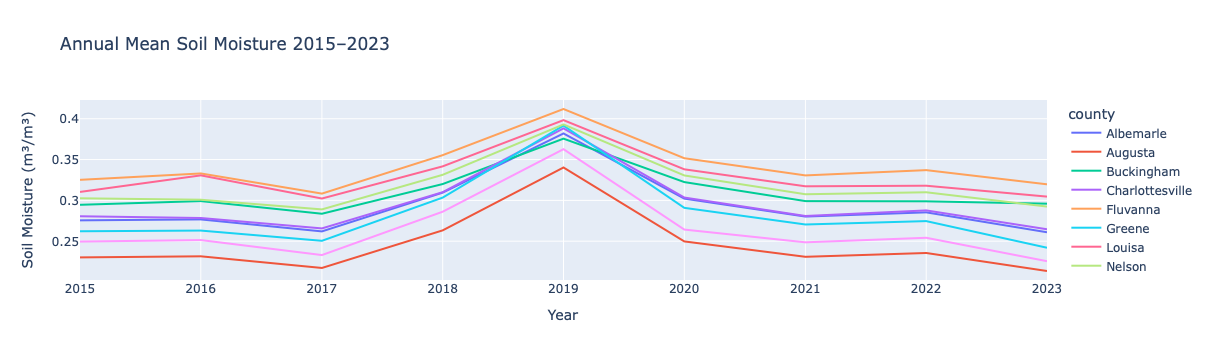

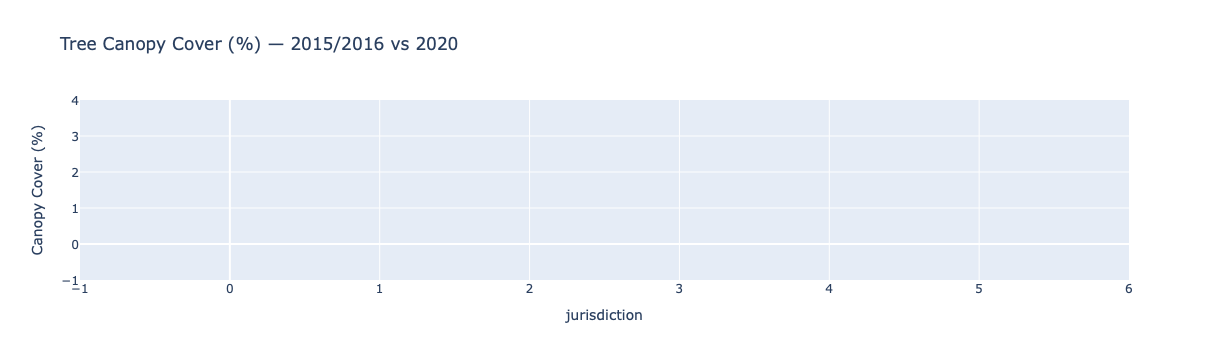

  Uploaded: s3://central-virginia-tree-canopy-project/dashboard-data/smap_annual_means.csv
  Uploaded: s3://central-va-tree-canopy-dashboard/data/smap_annual_means.csv
  Uploaded: s3://central-virginia-tree-canopy-project/dashboard-data/canopy_cover_bar.json
  Uploaded: s3://central-va-tree-canopy-dashboard/data/canopy_cover_bar.json
  Uploaded: s3://central-virginia-tree-canopy-project/dashboard-data/smap_timeseries.png
  Uploaded: s3://central-va-tree-canopy-dashboard/data/smap_timeseries.png
  Uploaded: s3://central-virginia-tree-canopy-project/dashboard-data/canopy_summary.csv
  Uploaded: s3://central-va-tree-canopy-dashboard/data/canopy_summary.csv
  Uploaded: s3://central-virginia-tree-canopy-project/dashboard-data/metadata.json
  Uploaded: s3://central-va-tree-canopy-dashboard/data/metadata.json
  Uploaded: s3://central-virginia-tree-canopy-project/dashboard-data/canopy_summary.json
  Uploaded: s3://central-va-tree-canopy-dashboard/data/canopy_summary.json
  Uploaded: s3://centr

In [15]:
import plotly.express as px
import plotly.io as pio

CONTENT_TYPES = {
    ".json": "application/json",
    ".csv":  "text/csv",
    ".png":  "image/png",
    ".html": "text/html",
}

# ── Chart A: SMAP Soil Moisture Time Series ───────────────────────────────────
fig_smap = px.line(
    smap_df,
    x      = "date",
    y      = "sm_mean_m3m3",
    color  = "county",
    title  = "Annual Mean Soil Moisture 2015–2023",
    labels = {"sm_mean_m3m3": "Soil Moisture (m³/m³)", "date": "Year"},
)
pio.write_json(fig_smap,   f"{OUTPUT_DIR}/smap_timeseries.json")
fig_smap.write_image(      f"{OUTPUT_DIR}/smap_timeseries.png", width=900, height=450)
fig_smap.show()

# ── Chart B: Canopy Cover Comparison Bar Chart ────────────────────────────────
fig_canopy = px.bar(
    canopy_df,
    x       = "jurisdiction",
    y       = ["canopy_2015_pct", "canopy_2020_pct"],
    barmode = "group",
    title   = "Tree Canopy Cover (%) — 2015/2016 vs 2020",
    labels  = {"value": "Canopy Cover (%)", "variable": "Year"},
)
pio.write_json(fig_canopy, f"{OUTPUT_DIR}/canopy_cover_bar.json")
fig_canopy.write_image(    f"{OUTPUT_DIR}/canopy_cover_bar.png", width=900, height=450)
fig_canopy.show()

# ── Export CSVs and JSONs ─────────────────────────────────────────────────────
smap_df.to_csv(   f"{OUTPUT_DIR}/smap_annual_means.csv",  index=False)
#smap_df.to_json(  f"{OUTPUT_DIR}/smap_annual_means.json", orient="records", indent=2)
smap_df_export = smap_df.copy()
smap_df_export["date"] = smap_df_export["date"].dt.strftime("%Y-%m-%d")
smap_df_export.to_json(f"{OUTPUT_DIR}/smap_annual_means.json", orient="records", indent=2)

canopy_df.to_csv( f"{OUTPUT_DIR}/canopy_summary.csv",     index=False)
canopy_df.to_json(f"{OUTPUT_DIR}/canopy_summary.json",    orient="records", indent=2)

metadata = {
    "project_title" : "Central Virginia Tree Canopy Change Detection",
    "last_updated"  : pd.Timestamp.now().strftime("%Y-%m-%d"),
    "smap_years"    : sorted(smap_df["year"].unique().tolist()),
    "jurisdictions" : sorted(canopy_df["jurisdiction"].tolist()),
}
with open(f"{OUTPUT_DIR}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# ── Upload all exports to S3 ──────────────────────────────────────────────────
uploaded = []
for fname in os.listdir(OUTPUT_DIR):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(fpath):
        ext = os.path.splitext(fname)[1].lower()
        content_type = CONTENT_TYPES.get(ext, "application/octet-stream")
        s3_key = EXPORT_PREFIX + fname
        s3.upload_file(
            fpath, BUCKET, s3_key,
            ExtraArgs={"ContentType": content_type}
        )
        uploaded.append(s3_key)

        # Place generated data into React App Data Location
        s3_reacy_app_key = REACT_APP_DATA_BUCKET_EXPORT_PREFIX + fname
        s3.upload_file(
            fpath, REACT_APP_DATA_BUCKET, s3_key,
            ExtraArgs={"ContentType": content_type}
        )
        uploaded.append(s3_reacy_app_key)

        #s3_key = REACT_APP_DATA_BUCKET_EXPORT_PREFIX + fname
        #s3.upload_file(fpath, BUCKET, s3_key)
        #uploaded.append(s3_key)
        print(f"  Uploaded: s3://{BUCKET}/{s3_key}")
        print(f"  Uploaded: s3://{REACT_APP_DATA_BUCKET}/{s3_reacy_app_key}")

print(f"\nAll exports complete. {len(uploaded)} files uploaded to S3.")